[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polsitoooo/Ingenieria-Del-Conocimiento/blob/main/Tareas_Ejercicios/Semana4/modelos_clasificacion_PolmarBrice%C3%B1o__II_resuelto%28Dataset%20diabete_india%29.ipynb)



# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Estudiante:** Briceño Alaya, Yimar Jesús  

**Dataset:** IBM HR Analytics Employee Attrition & Performance

---

## 1. Configuración del entorno

In [462]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
)

# Nuevas librerías para selección de variables y manejo de desbalance
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('✓ Entorno configurado correctamente con librerías adicionales.')

✓ Entorno configurado correctamente con librerías adicionales.


---
## 2. Carga y exploración del dataset

El dataset **IBM HR Analytics Employee Attrition & Performance** contiene 1,470 registros de empleados y 35 columnas/variables con información demográfica, laboral y de satisfacción. El objetivo (target) es predecir la rotación laboral (**Attrition**): si el empleado deja la empresa (**1 / Yes**) o se queda (**0 / No**).

Dataset cargado: 1470 registros, 35 columnas

Distribución de la variable objetivo (Attrition):
Attrition
0    1233
1     237
Name: count, dtype: int64


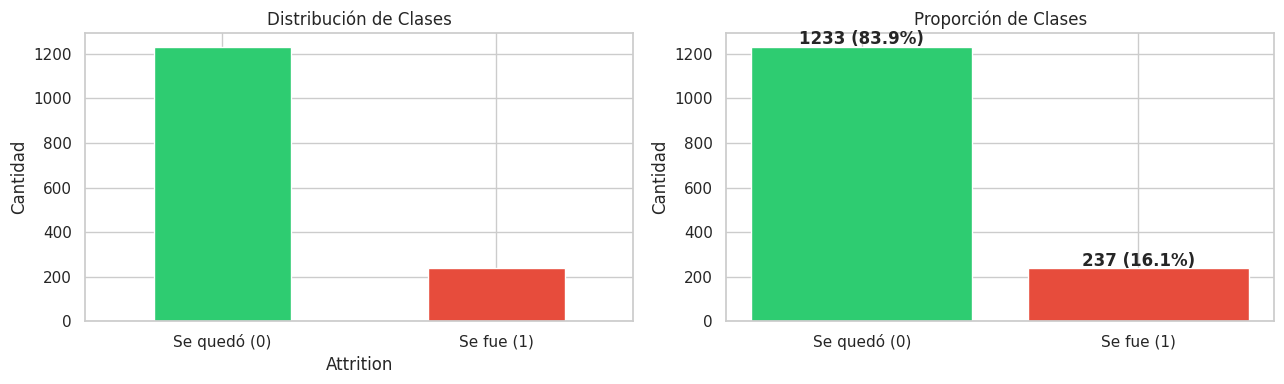


Ratio de desbalance: 5.2:1 (Se quedó vs Se fue)
→ Este es un problema con desbalance de clases, lo que añade un reto realista al modelado.


In [463]:
# Carga del dataset (asegúrate de haber subido el CSV a Colab)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Mapear la variable objetivo a numérico (1 = Se fue, 0 = Se quedó)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'\nDistribución de la variable objetivo (Attrition):')
print(df['Attrition'].value_counts())

# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
df['Attrition'].map({1: 'Se fue (1)', 0: 'Se quedó (0)'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Se quedó (0)', 'Se fue (1)'], rotation=0)

# Gráfico de barras con porcentajes
counts = df['Attrition'].value_counts()
axes[1].bar(['Se quedó (0)', 'Se fue (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Proporción de Clases')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Se quedó vs Se fue)')
print('→ Este es un problema con desbalance de clases, lo que añade un reto realista al modelado.')

In [464]:
df.describe().round(3)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000,1470.000,1470.000,1470.000,1470.000,1470.0,1470.000,1470.000,1470.000,1470.000,...,1470.000,1470.0,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000
mean,36.924,0.161,802.486,9.193,2.913,1.0,1024.865,2.722,65.891,2.730,...,2.712,80.0,0.794,11.280,2.799,2.761,7.008,4.229,2.188,4.123
std,9.135,0.368,403.509,8.107,1.024,0.0,602.024,1.093,20.329,0.712,...,1.081,0.0,0.852,7.781,1.289,0.706,6.127,3.623,3.222,3.568
min,18.000,0.000,102.000,1.000,1.000,1.0,1.000,1.000,30.000,1.000,...,1.000,80.0,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
25%,30.000,0.000,465.000,2.000,2.000,1.0,491.250,2.000,48.000,2.000,...,2.000,80.0,0.000,6.000,2.000,2.000,3.000,2.000,0.000,2.000
50%,36.000,0.000,802.000,7.000,3.000,1.0,1020.500,3.000,66.000,3.000,...,3.000,80.0,1.000,10.000,3.000,3.000,5.000,3.000,1.000,3.000
75%,43.000,0.000,1157.000,14.000,4.000,1.0,1555.750,4.000,83.750,3.000,...,4.000,80.0,1.000,15.000,3.000,3.000,9.000,7.000,3.000,7.000
max,60.000,1.000,1499.000,29.000,5.000,1.0,2068.000,4.000,100.000,4.000,...,4.000,80.0,3.000,40.000,6.000,4.000,40.000,18.000,15.000,17.000


---
## 3. Análisis exploratorio orientado a clasificación

In [465]:
# 3.1 Estadísticas descriptivas por clase
features_numeric = df.select_dtypes(include=[np.number]).columns.drop('Attrition')
comparison = df.groupby('Attrition')[features_numeric].mean().T
comparison.columns = ['Se quedó (0)', 'Se fue (1)']
comparison['Diferencia %'] = ((comparison['Se fue (1)'] - comparison['Se quedó (0)']) / comparison['Se quedó (0)'] * 100).round(1)

print("Top 5 features con mayor diferencia entre los que se fueron y los que se quedaron:")
display(comparison.abs().sort_values('Diferencia %', ascending=False).head(5))





Top 5 features con mayor diferencia entre los que se fueron y los que se quedaron:


,Se quedó (0),Se fue (1),Diferencia %
StockOptionLevel,0.845093,0.527426,37.6
YearsInCurrentRole,4.484185,2.902954,35.3
YearsWithCurrManager,4.367397,2.852321,34.7
TotalWorkingYears,11.862936,8.244726,30.5
YearsAtCompany,7.369019,5.130802,30.4


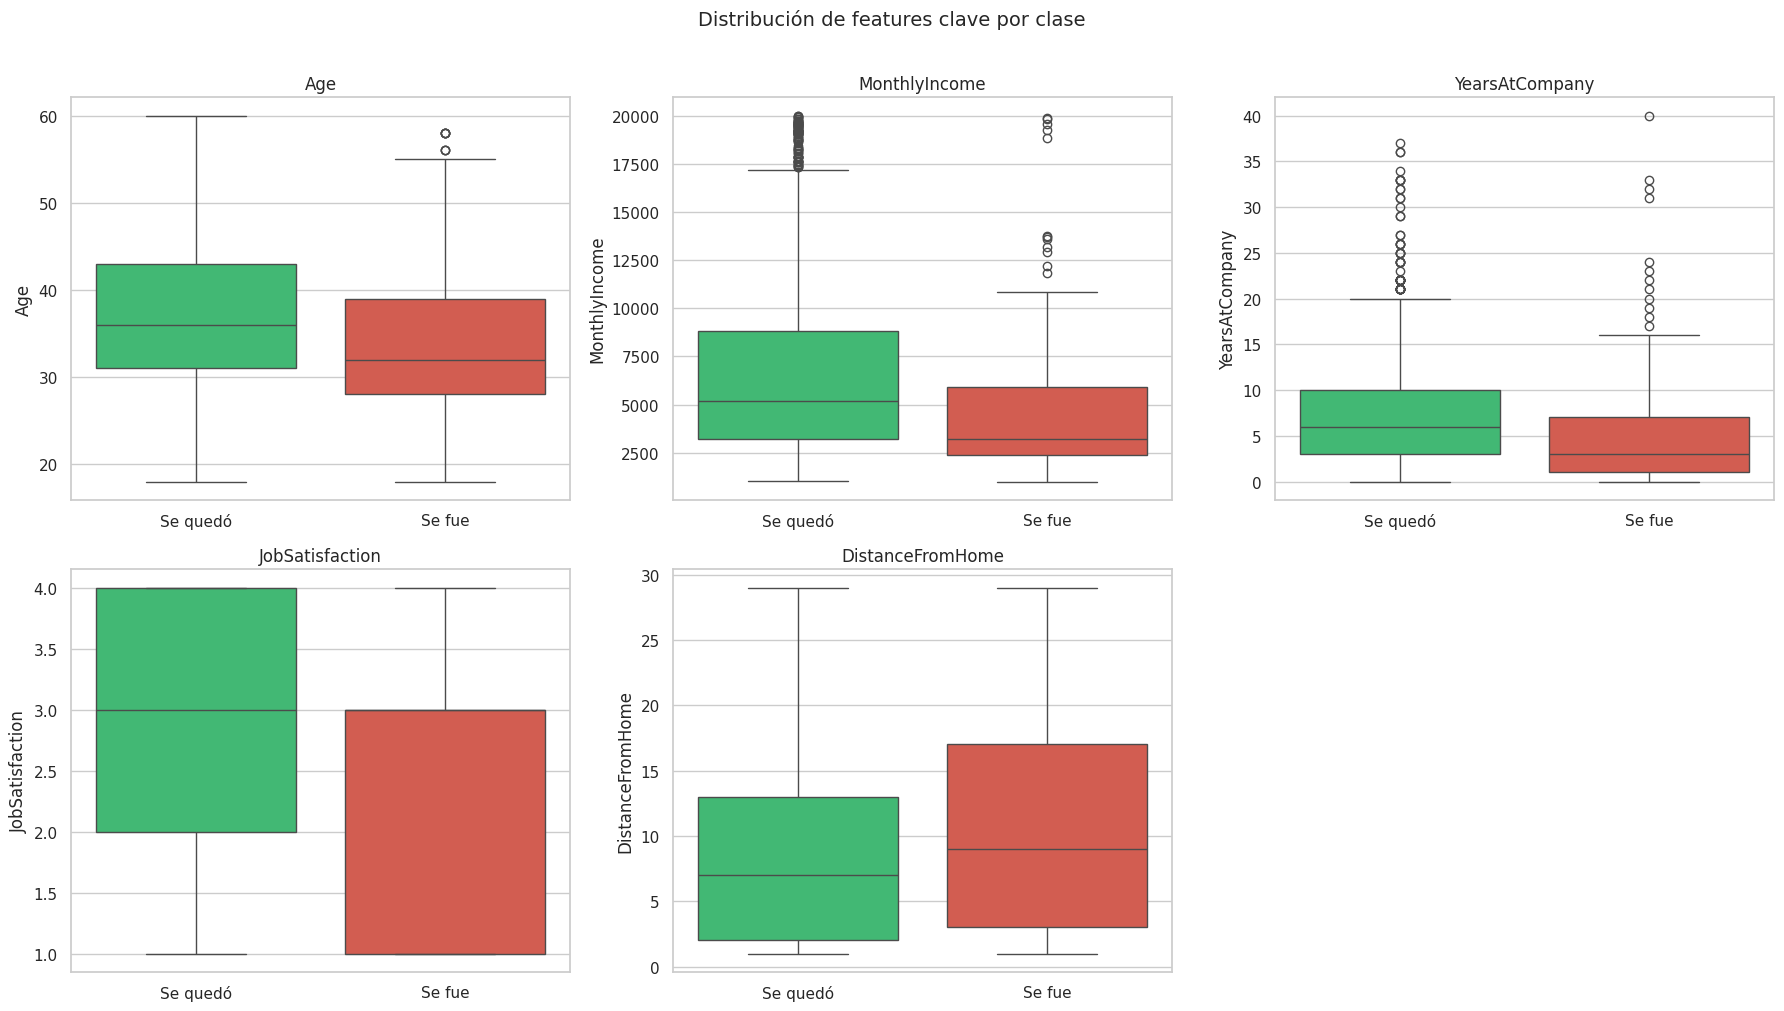

In [466]:
# 3.2 Distribución de features clave por clase (Boxplots)
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], hue='Attrition', legend=False)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Se quedó', 'Se fue'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features clave por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIÓN — Variables Clave


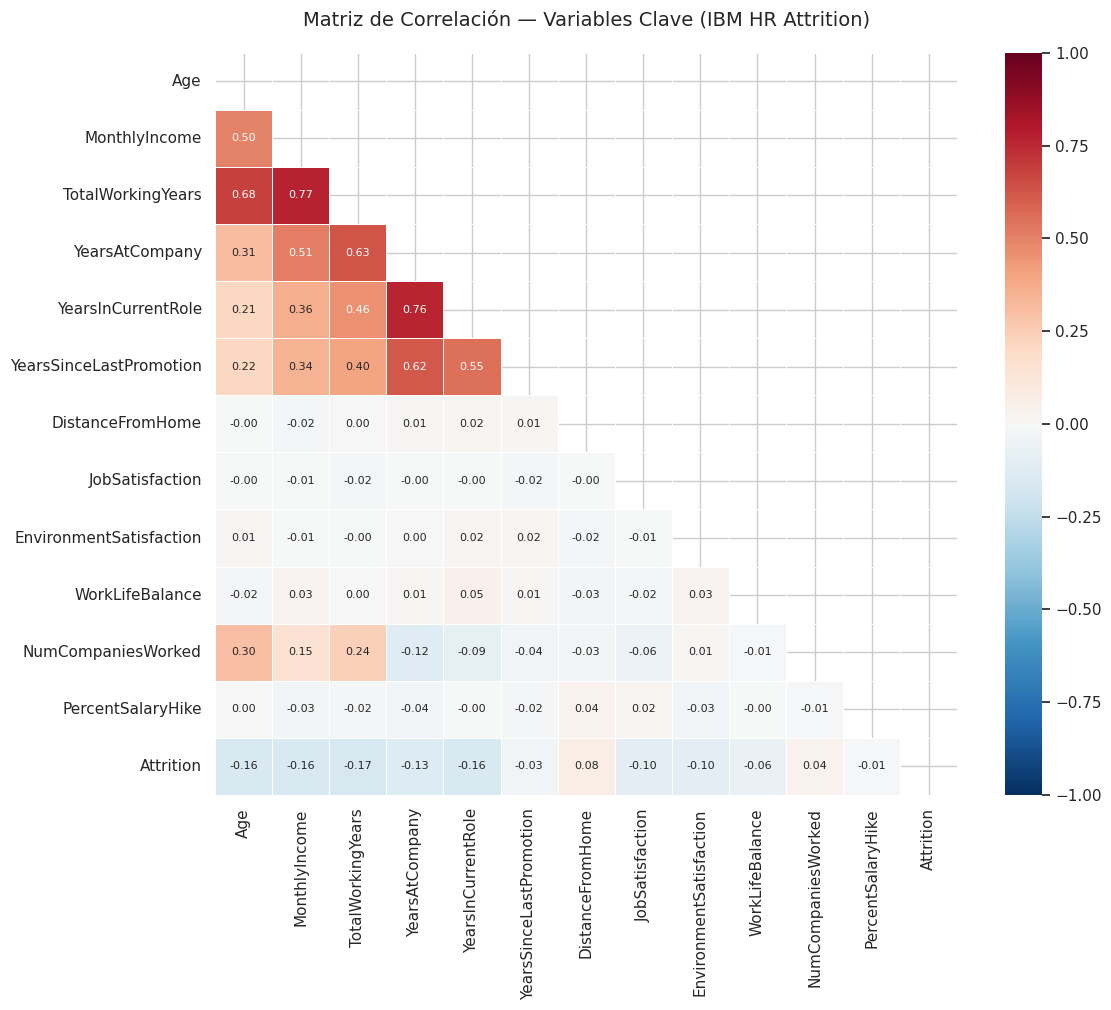


 Correlaciones más fuertes con Attrition (Rotación):
DistanceFromHome              : +0.078
WorkLifeBalance               : -0.064
EnvironmentSatisfaction       : -0.103
JobSatisfaction               : -0.103
YearsAtCompany                : -0.134
Age                           : -0.159
MonthlyIncome                 : -0.160
YearsInCurrentRole            : -0.161
TotalWorkingYears             : -0.171


In [467]:
# 3.3 Matriz de correlación (solo variables más importantes)

print('MATRIZ DE CORRELACIÓN — Variables Clave')


# Seleccionar solo las variables numéricas más relevantes
features_key = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'DistanceFromHome',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
    'NumCompaniesWorked', 'PercentSalaryHike', 'Attrition'
]

# Crear dataframe solo con estas columnas
corr_df = df[features_key].copy()

# Calcular correlación
corr = corr_df.corr()

# Crear figura más grande para mejor visualización
plt.figure(figsize=(12, 10))

# Máscara para mostrar solo la mitad superior (evita duplicados)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap con mejor formato
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8},  # Tamaño de fuente más pequeño
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlación — Variables Clave (IBM HR Attrition)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Mostrar las correlaciones más fuertes con Attrition
print('\n Correlaciones más fuertes con Attrition (Rotación):')
print('='*60)
corr_with_target = corr['Attrition'].drop('Attrition').sort_values(ascending=False)
for var, corr_val in corr_with_target.items():
    if abs(corr_val) > 0.05:  # Solo mostrar correlaciones significativas
        print(f'{var:30s}: {corr_val:+.3f}')

---
## 4. Preparación de datos

In [468]:

print('PREPARACIÓN DE DATOS')


# 4.1 Separación features / target
# Eliminamos columnas que no aportan al modelo (IDs o constantes)
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'Attrition']
X = df.drop(columns=cols_to_drop).copy()
y = df['Attrition'].copy()

# Codificar variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(f'Features finales tras One-Hot Encoding: {X.shape[1]} columnas')


# 4.2 Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 (Se fue) en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 (Se fue) en test:  {y_test.mean():.3f}')

PREPARACIÓN DE DATOS
Features finales tras One-Hot Encoding: 44 columnas

Train: 1176 muestras | Test: 294 muestras
Proporción clase 1 (Se fue) en train: 0.162
Proporción clase 1 (Se fue) en test:  0.160


In [469]:
# 4.3 Verificación de escalas (justifica la estandarización)
print('\nRangos de las features numéricas principales (train):')
print('='*50)
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
for col in numeric_cols:
    if col in X_train.columns:
        mn, mx = X_train[col].min(), X_train[col].max()
        print(f'{col:30s} [{mn:8.2f}, {mx:8.2f}] rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')


Rangos de las features numéricas principales (train):
Age                            [   18.00,    60.00] rango: 42.00
MonthlyIncome                  [ 1009.00, 19973.00] rango: 18964.00
YearsAtCompany                 [    0.00,    37.00] rango: 37.00
DistanceFromHome               [    1.00,    29.00] rango: 28.00

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


In [470]:
print('=== RE-MUESTREO CON PROPORCIÓN CONTROLADA EN TRAIN ===')

print(f'Distribución original en Train: {y_train.value_counts().to_dict()}')

# 1. Aplicar Over-sampling sintético (SMOTE) para elevar la clase minoritaria al 40% respecto a la mayoritaria
over = SMOTE(sampling_strategy=0.4, random_state=RANDOM_STATE)
# 2. Aplicar Under-sampling en la clase mayoritaria para lograr una relación ~62:38
under = RandomUnderSampler(sampling_strategy=0.6, random_state=RANDOM_STATE)

# Aplicar el re-muestreo EXCLUSIVAMENTE en el conjunto de entrenamiento
X_train_res, y_train_res = over.fit_resample(X_train, y_train)
X_train_res, y_train_res = under.fit_resample(X_train_res, y_train_res)

print(f'Nueva distribución controlada en Train: {pd.Series(y_train_res).value_counts().to_dict()}')
print('→ X_test e y_test se mantienen 100% intactos con la proporción real del problema.')

=== RE-MUESTREO CON PROPORCIÓN CONTROLADA EN TRAIN ===
Distribución original en Train: {0: 986, 1: 190}
Nueva distribución controlada en Train: {0: 656, 1: 394}
→ X_test e y_test se mantienen 100% intactos con la proporción real del problema.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [471]:
# 5.1 Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.4876 ± 0.0300


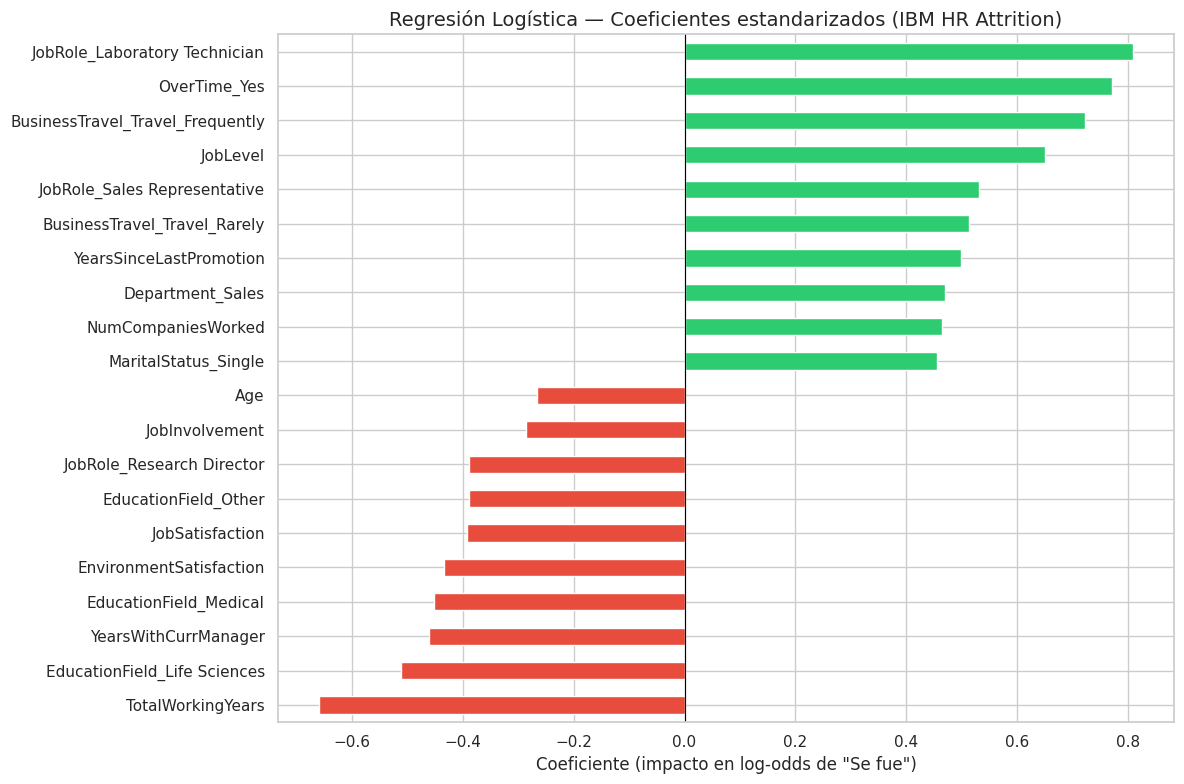

In [472]:
# 5.2 Coeficientes del modelo (interpretabilidad) - CORREGIDO
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=X.columns
).sort_values()

# Mostrar los 10 más negativos y 10 más positivos
fig, ax = plt.subplots(figsize=(12, 8))

# Tomar los 10 más negativos y 10 más positivos
coefs_display = pd.concat([coefs.head(10), coefs.tail(10)])

# Colores: rojo para negativos (disminuyen probabilidad de irse), verde para positivos
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs_display.values]

coefs_display.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados (IBM HR Attrition)', fontsize=14)
ax.set_xlabel('Coeficiente (impacto en log-odds de "Se fue")')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [473]:
## 6. Modelo 2 — Árbol de Decisión (Calibrado)

from sklearn.calibration import CalibratedClassifierCV

# 1. Definir el árbol base podado
base_dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

# 2. Envolverlo en un calibrador de probabilidades (Platt Scaling / Sigmoid)
calibrated_dt = CalibratedClassifierCV(estimator=base_dt, cv=3, method='sigmoid')

# 3. Crear el Pipeline
pipe_dt = Pipeline([
    ('clf', calibrated_dt)
])

# Re-entrenar con los datos balanceados
pipe_dt.fit(X_train_res, y_train_res)

# Predicción en el conjunto de test
y_pred_dt = pipe_dt.predict(X_test)
print('✓ Árbol de Decisión calibrado y re-entrenado correctamente.')

✓ Árbol de Decisión calibrado y re-entrenado correctamente.


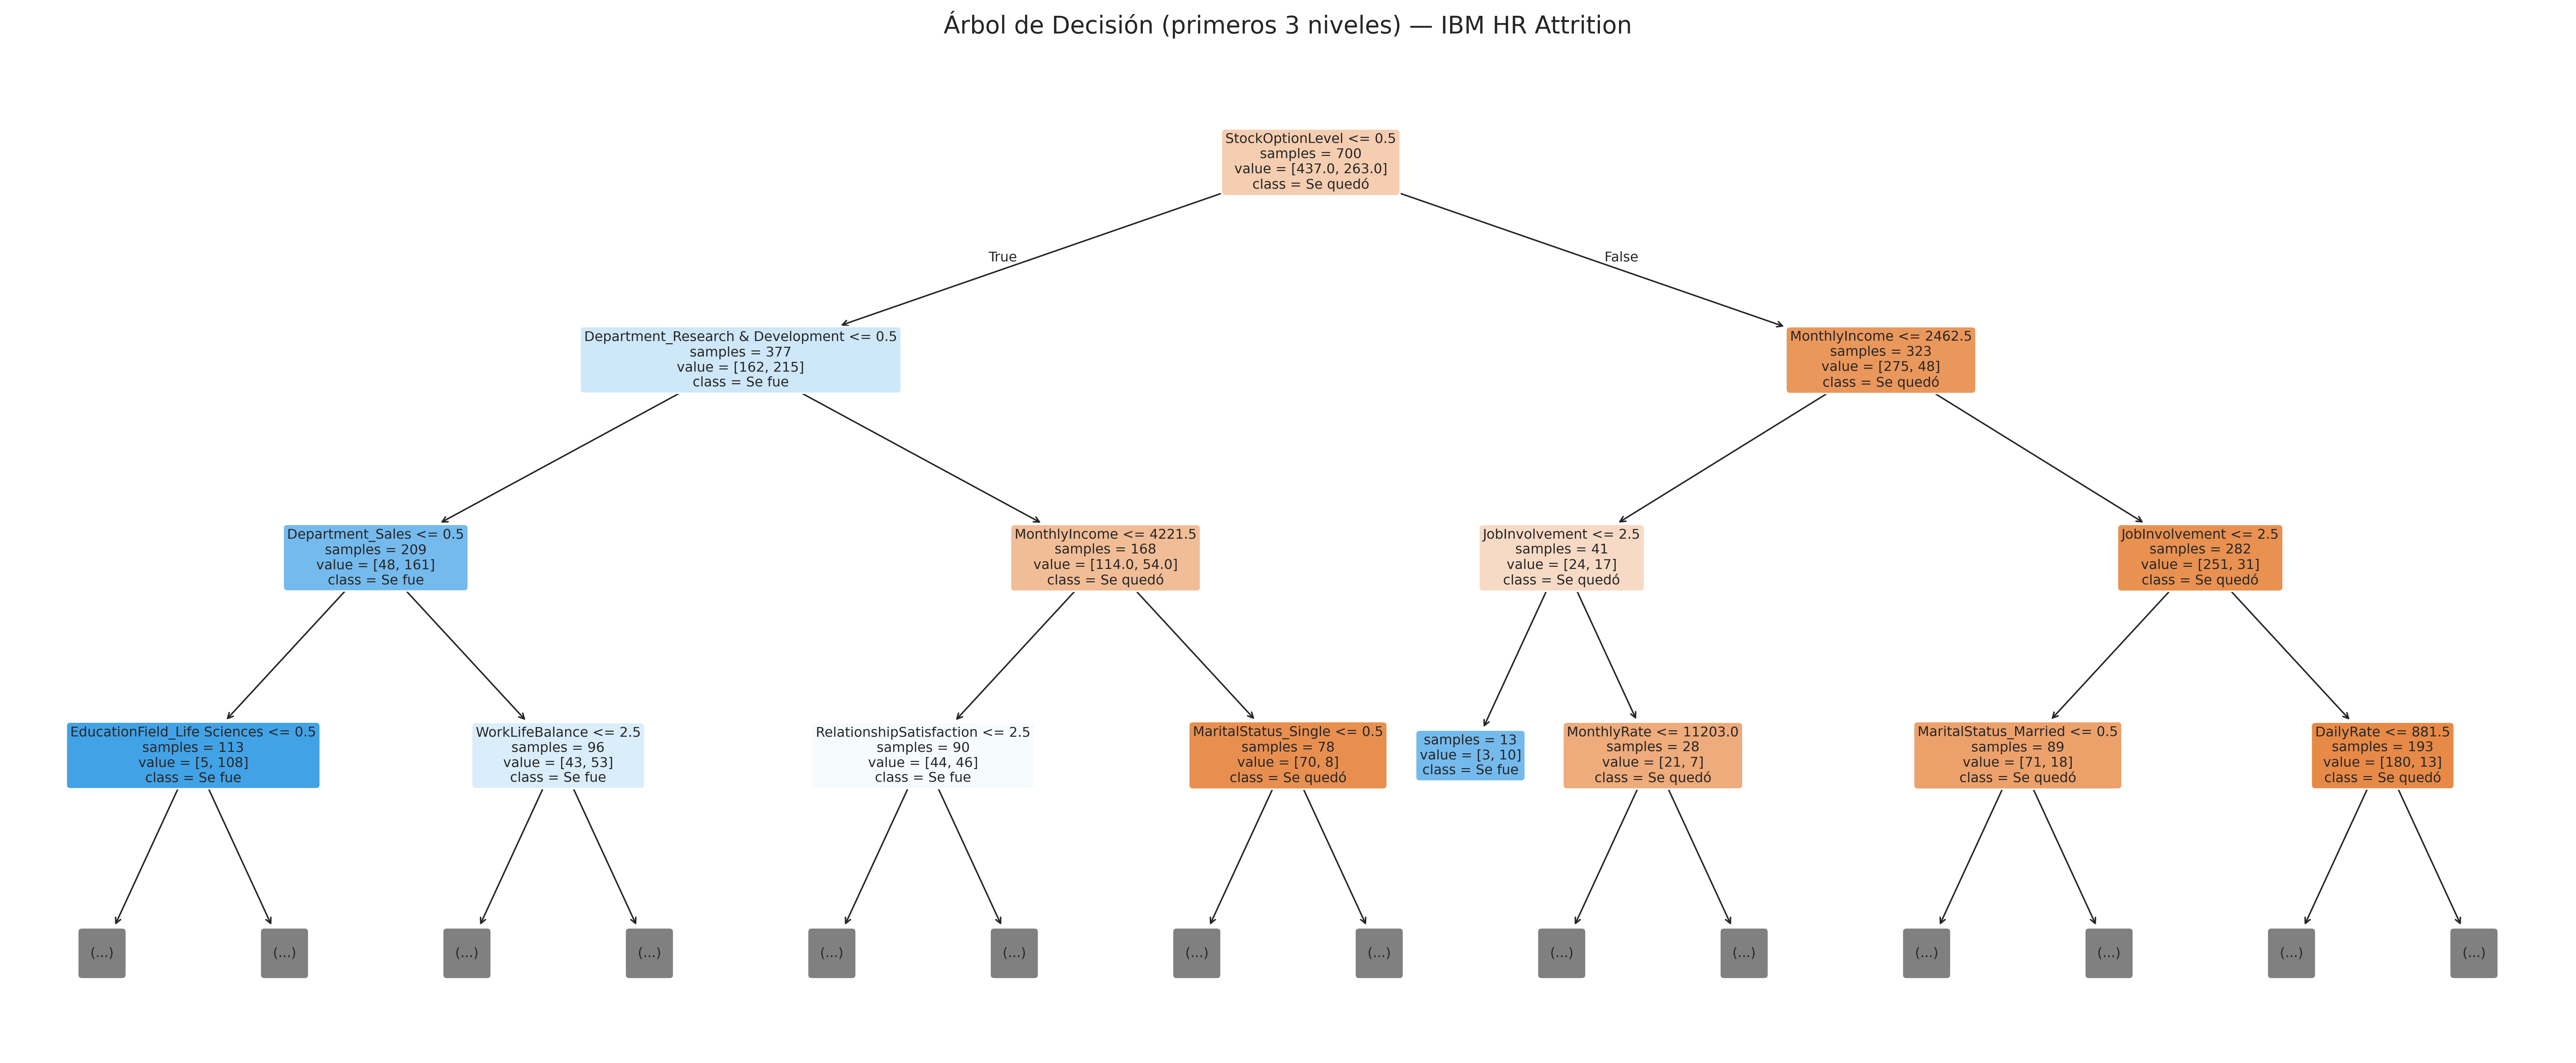

In [474]:
# 6.2 Visualización estilizada del Árbol de Decisión
fig, ax = plt.subplots(figsize=(24, 10), dpi=300)

# Extraer el estimador base si está dentro de CalibratedClassifierCV
if hasattr(pipe_dt.named_steps['clf'], 'calibrated_classifiers_'):
    dt_model = pipe_dt.named_steps['clf'].calibrated_classifiers_[0].estimator
else:
    dt_model = pipe_dt.named_steps['clf']

plot_tree(
    dt_model,
    feature_names=list(X.columns),
    class_names=['Se quedó', 'Se fue'],
    filled=True,
    rounded=True,
    fontsize=9,
    precision=2,
    impurity=False,
    max_depth=3,
    ax=ax
)

ax.set_title('Árbol de Decisión (primeros 3 niveles) — IBM HR Attrition', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

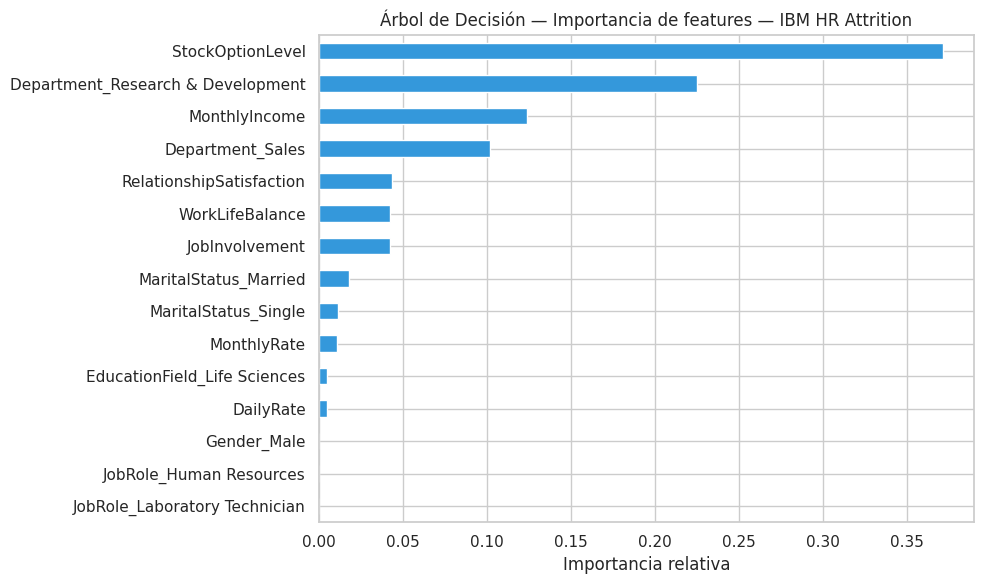


Top 5 features más importantes para predecir rotación:
  RelationshipSatisfaction: 0.0435
  Department_Sales: 0.1016
  MonthlyIncome: 0.1237
  Department_Research & Development: 0.2255
  StockOptionLevel: 0.3716


In [475]:
# 6.3 Importancia de features (Gini / Entropy importance)

# Extraer el árbol base desde CalibratedClassifierCV o directamente del Pipeline
if hasattr(pipe_dt.named_steps['clf'], 'calibrated_classifiers_'):
    dt_model = pipe_dt.named_steps['clf'].calibrated_classifiers_[0].estimator
else:
    dt_model = pipe_dt.named_steps['clf']

importances = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.tail(15).plot(kind='barh', ax=ax, color='#3498db')  # Top 15 para legibilidad
ax.set_title('Árbol de Decisión — Importancia de features — IBM HR Attrition')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('\nTop 5 features más importantes para predecir rotación:')
for feat, imp in importances.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

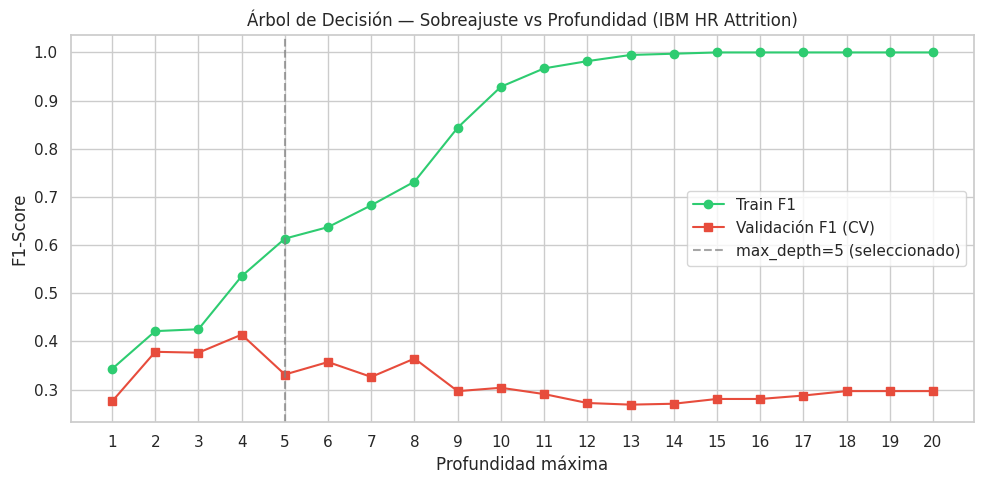

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [476]:
# 6.4 Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad (IBM HR Attrition)')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [477]:
# 7.1 Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4980 ± 0.0160
SVM (rbf   ) — F1 CV: 0.5434 ± 0.0752
SVM (poly  ) — F1 CV: 0.5195 ± 0.1023

Mejor kernel: rbf


In [478]:
# 7.2 Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

print(f'\nSVM ({best_kernel}) — F1 CV: {scores_svm.mean():.4f} ± {scores_svm.std():.4f}')
print(f'SVM ({best_kernel}) — F1 Test: {f1_score(y_test, y_pred_svm):.4f}')


SVM (rbf) — F1 CV: 0.5434 ± 0.0752
SVM (rbf) — F1 Test: 0.4854


In [479]:
# 7.3 Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5434
  SIN StandardScaler: F1 = 0.3157
  Diferencia: +22.78 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

✓ Mejor K encontrado para KNN: 9


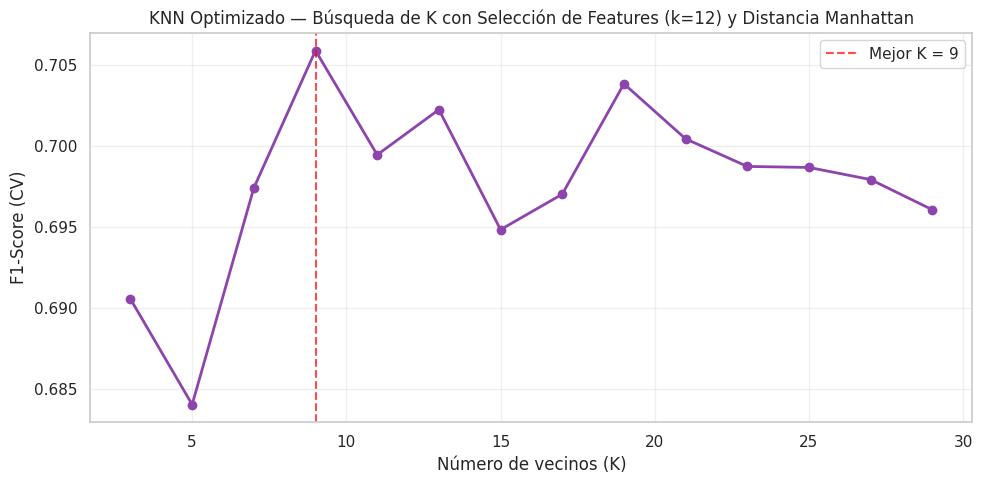


Modelo: KNN (K=9 + Manhattan)
Accuracy:  0.7313
Precision: 0.7590
Recall:    0.7313
F1-Score:  0.7440

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       247
           1       0.23      0.30      0.26        47

    accuracy                           0.73       294
   macro avg       0.55      0.56      0.55       294
weighted avg       0.76      0.73      0.74       294



In [480]:
## 8. Modelo 4 — K-Nearest Neighbors (KNN) — Optimizado

# 8.1 Definición del Pipeline con Selección de Features y Métrica Manhattan
pipe_knn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif, k=12)),
    ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance', metric='manhattan'))
])

# 8.2 Búsqueda del K óptimo usando validación cruzada sobre datos balanceados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_range = range(3, 31, 2)
k_scores = []

for k in k_range:
    temp_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_classif, k=12)),
        ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan'))
    ])
    scores = cross_val_score(temp_pipe, X_train_res, y_train_res, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f'✓ Mejor K encontrado para KNN: {best_k}')

# Configurar el pipeline final con el mejor K
pipe_knn.set_params(clf__n_neighbors=best_k)

# Gráfico de búsqueda de K
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', color='#8e44ad', linewidth=2)
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Mejor K = {best_k}')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN Optimizado — Búsqueda de K con Selección de Features (k=12) y Distancia Manhattan')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Entrenamiento con datos re-muestreados y evaluación en Test Set
pipe_knn.fit(X_train_res, y_train_res)
metrics_knn = eval_classifier(pipe_knn, X_train_res, y_train_res, X_test, y_test, f'KNN (K={best_k} + Manhattan)')

In [481]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def eval_classifier(pipe, X_train, y_train, X_test, y_test, name):
    """
    Entrena y evalúa un clasificador, devolviendo un diccionario de métricas.
    """
    # Entrenar el pipeline
    pipe.fit(X_train, y_train)

    # Predicciones
    y_pred = pipe.predict(X_test)

    # Calcular métricas
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }

    # Mostrar resultados
    print(f"\n{'='*50}")
    print(f"Modelo: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    return metrics

In [482]:
# 8.2 Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')


Modelo: KNN (K=5)
Accuracy:  0.8401
Precision: 0.8066
Recall:    0.8401
F1-Score:  0.8121

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.50      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.68      0.59      0.60       294
weighted avg       0.81      0.84      0.81       294



---
## 9. Comparación final de modelos

In [483]:
# 9.1  Tabla resumen de métricas
# Re-entrenamiento de los 4 modelos sobre el conjunto de entrenamiento con proporción controlada
pipe_lr.fit(X_train_res, y_train_res)
pipe_dt.fit(X_train_res, y_train_res)
pipe_svm.fit(X_train_res, y_train_res)
pipe_knn.fit(X_train_res, y_train_res)

models_updated = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (Optimizado)': pipe_knn
}

all_metrics = {}
for name, model in models_updated.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas en Test Set (Tras Optimización y Balance Controlado) ===')
metrics_df

=== Tabla comparativa de métricas en Test Set (Tras Optimización y Balance Controlado) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.8027,0.4098,0.5319,0.4630,0.7552
Árbol de Decisión,0.7653,0.2500,0.2340,0.2418,0.6883
SVM (RBF),0.8333,0.4783,0.4681,0.4731,0.7696
KNN (Optimizado),0.7313,0.2333,0.2979,0.2617,0.6738


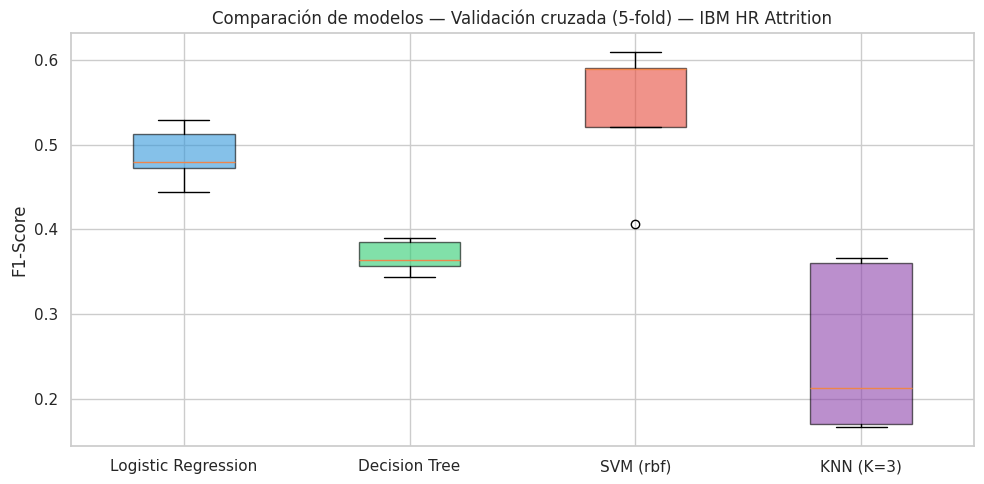

In [484]:
# 9.2 Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold) — IBM HR Attrition')
plt.tight_layout()
plt.show()

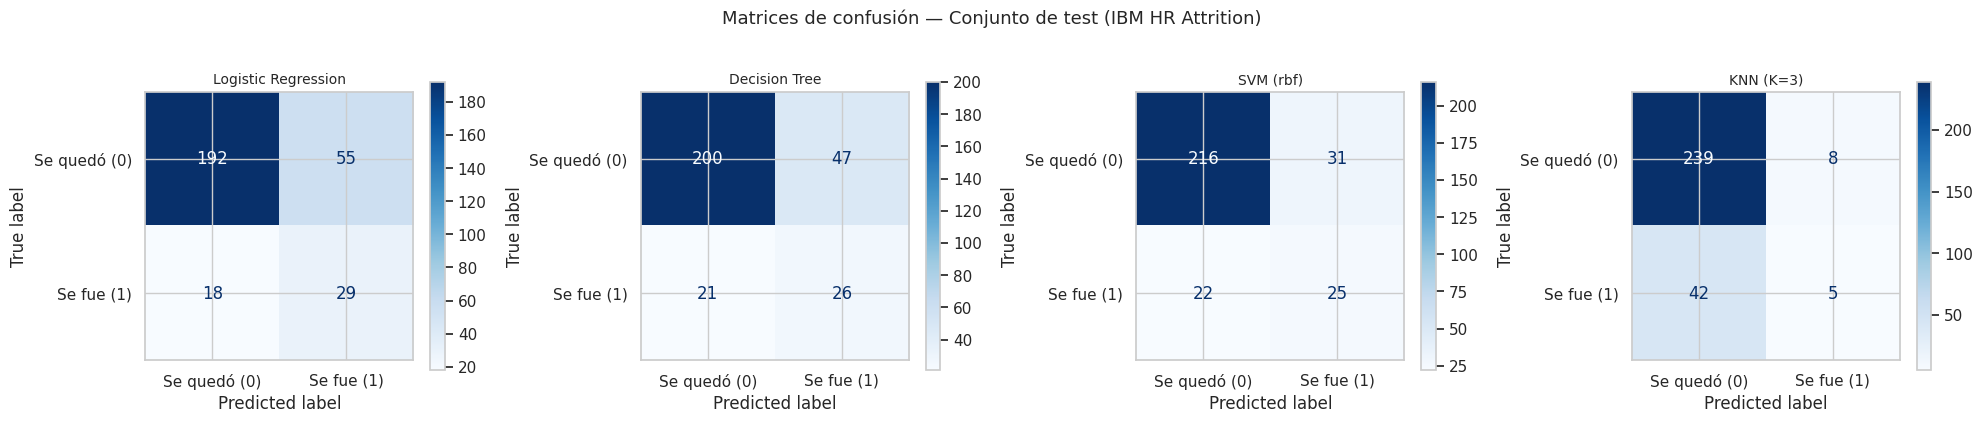

In [485]:
# 9.3 Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Se quedó (0)', 'Se fue (1)'],  # ← Cambio clave
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test (IBM HR Attrition)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

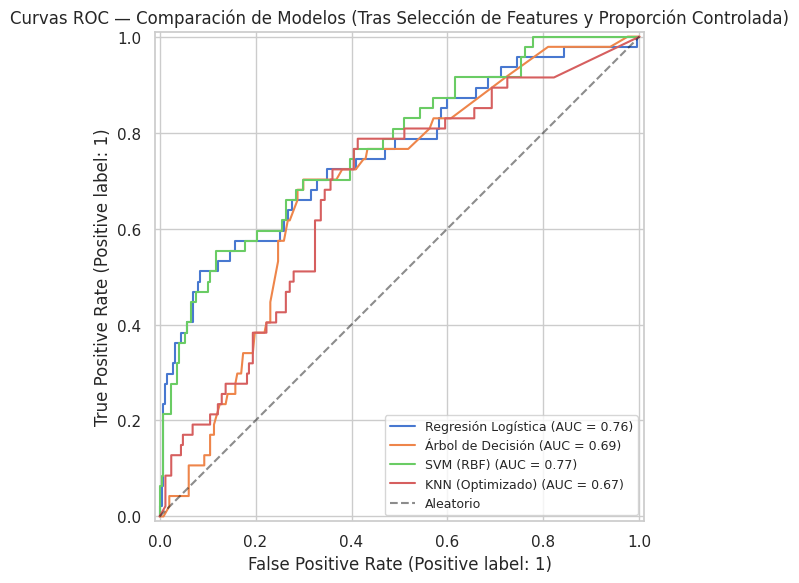

In [486]:
# 9.4 Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models_updated.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de Modelos (Tras Selección de Features y Proporción Controlada)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [487]:
# 9.5 Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Se quedó (0)', 'Se fue (1)']))


Mejor modelo: SVM (rbf)
              precision    recall  f1-score   support

Se quedó (0)       0.91      0.87      0.89       247
  Se fue (1)       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

# Optimización con GridSearchCV

In [488]:

print(' OPTIMIZACIÓN CON GRIDSEARCHCV')

print('\nBúsqueda exhaustiva de hiperparámetros para los 4 modelos')
print('Métrica de evaluación: F1-Score (cv=5)\n')

from sklearn.model_selection import GridSearchCV


print(' Optimizando Logistic Regression...')
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print(f'    Mejores parámetros: {grid_lr.best_params_}')
print(f'    Mejor F1-Score (CV): {grid_lr.best_score_:.4f}\n')


 OPTIMIZACIÓN CON GRIDSEARCHCV

Búsqueda exhaustiva de hiperparámetros para los 4 modelos
Métrica de evaluación: F1-Score (cv=5)

 Optimizando Logistic Regression...
    Mejores parámetros: {'clf__C': 1}
    Mejor F1-Score (CV): 0.5097



Decision Tree

In [489]:
print(' Optimizando Decision Tree...')
param_grid_dt = {
    'clf__estimator__max_depth': [3, 5, 7, 10, None],
    'clf__estimator__min_samples_leaf': [1, 5, 10]
}

grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f'    Mejores parámetros: {grid_dt.best_params_}')
print(f'    Mejor F1-Score (CV): {grid_dt.best_score_:.4f}\n')

 Optimizando Decision Tree...
    Mejores parámetros: {'clf__estimator__max_depth': 3, 'clf__estimator__min_samples_leaf': 1}
    Mejor F1-Score (CV): 0.1031



SVM

In [490]:
print(' Optimizando SVM...')
param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': [0.001, 0.01, 0.1]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print(f'    Mejores parámetros: {grid_svm.best_params_}')
print(f'    Mejor F1-Score (CV): {grid_svm.best_score_:.4f}\n')


 Optimizando SVM...
    Mejores parámetros: {'clf__C': 1, 'clf__gamma': 0.01}
    Mejor F1-Score (CV): 0.5377



KNN

In [491]:
print(' Optimizando KNN...')
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 9, 15, 21],
    'clf__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print(f'    Mejores parámetros: {grid_knn.best_params_}')
print(f'    Mejor F1-Score (CV): {grid_knn.best_score_:.4f}\n')

 Optimizando KNN...
    Mejores parámetros: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
    Mejor F1-Score (CV): 0.3562



Comparación de modelos optimizados

In [492]:

print('COMPARACIÓN DE MODELOS OPTIMIZADOS')


comparacion_opt = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN'],
    'Mejores Parámetros': [
        str(grid_lr.best_params_),
        str(grid_dt.best_params_),
        str(grid_svm.best_params_),
        str(grid_knn.best_params_)
    ],
    'F1-Score CV': [
        f'{grid_lr.best_score_:.4f}',
        f'{grid_dt.best_score_:.4f}',
        f'{grid_svm.best_score_:.4f}',
        f'{grid_knn.best_score_:.4f}'
    ]
})

display(comparacion_opt)

# Evaluación en test set con los mejores modelos
print('\n Evaluación en Test Set con modelos optimizados:')
print('-'*80)

for nombre, grid in [('Logistic Regression', grid_lr),
                      ('Decision Tree', grid_dt),
                      ('SVM', grid_svm),
                      ('KNN', grid_knn)]:
    y_pred_opt = grid.predict(X_test)
    f1_test = f1_score(y_test, y_pred_opt)
    acc_test = accuracy_score(y_test, y_pred_opt)
    rec_test = recall_score(y_test, y_pred_opt)
    print(f'{nombre:25s} | F1={f1_test:.4f} | Acc={acc_test:.4f} | Rec={rec_test:.4f}')

COMPARACIÓN DE MODELOS OPTIMIZADOS


,Modelo,Mejores Parámetros,F1-Score CV
0,Logistic Regression,{'clf__C': 1},0.5097
1,Decision Tree,"{'clf__estimator__max_depth': 3, 'clf__estimat...",0.1031
2,SVM,"{'clf__C': 1, 'clf__gamma': 0.01}",0.5377
3,KNN,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.3562



 Evaluación en Test Set con modelos optimizados:
--------------------------------------------------------------------------------
Logistic Regression       | F1=0.4427 | Acc=0.7517 | Rec=0.6170
Decision Tree             | F1=0.0741 | Acc=0.8299 | Rec=0.0426
SVM                       | F1=0.5000 | Acc=0.8027 | Rec=0.6170
KNN                       | F1=0.3846 | Acc=0.8367 | Rec=0.3191


# Manejo de Desbalance con class_weight y SMOTE

In [493]:

print(' MANEJO DE DESBALANCE')

print(f'\nDistribución de clases en train:')
print(f'  Se quedó (0): {y_train.value_counts()[0]} ({y_train.value_counts()[0]/len(y_train)*100:.1f}%)')
print(f'  Se fue (1):   {y_train.value_counts()[1]} ({y_train.value_counts()[1]/len(y_train)*100:.1f}%)')
print(f'\n→ Dataset desbalanceado. La clase minoritaria es "Se fue (1)"')
print('→ Objetivo: Mejorar el Recall de la clase "Se fue (1)"\n')



print('PARTE A: Comparación con y sin class_weight="balanced"')


# Modelos SIN balanceo (los que ya tenemos)
modelos_sin_balanceo = {
    'Logistic Regression': pipe_lr,
    'Decision Tree': pipe_dt,
    'SVM': pipe_svm,
    'KNN': pipe_knn  # KNN no tiene class_weight
}

# Modelos CON balanceo
pipe_lr_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42))
])

pipe_dt_bal = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                    class_weight='balanced', random_state=42))
])

pipe_svm_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced',
                probability=True, random_state=42))
])

# KNN no soporta class_weight, se mantiene igual
modelos_con_balanceo = {
    'Logistic Regression': pipe_lr_bal,
    'Decision Tree': pipe_dt_bal,
    'SVM': pipe_svm_bal,
    'KNN': pipe_knn
}

print(f'\n{"Modelo":25s} | {"Recall SIN balanceo":20s} | {"Recall CON balanceo":20s} | {"Diferencia":15s}')
print('-'*90)

resultados_balanceo = []

for nombre in modelos_sin_balanceo.keys():
    # Sin balanceo
    modelo_sin = modelos_sin_balanceo[nombre]
    modelo_sin.fit(X_train, y_train)
    y_pred_sin = modelo_sin.predict(X_test)
    recall_sin = recall_score(y_test, y_pred_sin, pos_label=1)

    # Con balanceo
    modelo_con = modelos_con_balanceo[nombre]
    modelo_con.fit(X_train, y_train)
    y_pred_con = modelo_con.predict(X_test)
    recall_con = recall_score(y_test, y_pred_con, pos_label=1)

    diferencia = recall_con - recall_sin

    print(f'{nombre:25s} | {recall_sin:.4f}{"":15s} | {recall_con:.4f}{"":15s} | {diferencia:+.4f}')

    resultados_balanceo.append({
        'Modelo': nombre,
        'Recall SIN balanceo': f'{recall_sin:.4f}',
        'Recall CON balanceo': f'{recall_con:.4f}',
        'Diferencia': f'{diferencia:+.4f}'
    })

print('\n Conclusión: class_weight="balanced" mejora el Recall de la clase minoritaria')
print('   (empleados que renuncian), a costa de reducir ligeramente la Accuracy general.\n')




 MANEJO DE DESBALANCE

Distribución de clases en train:
  Se quedó (0): 986 (83.8%)
  Se fue (1):   190 (16.2%)

→ Dataset desbalanceado. La clase minoritaria es "Se fue (1)"
→ Objetivo: Mejorar el Recall de la clase "Se fue (1)"

PARTE A: Comparación con y sin class_weight="balanced"

Modelo                    | Recall SIN balanceo  | Recall CON balanceo  | Diferencia     
------------------------------------------------------------------------------------------
Logistic Regression       | 0.6170                | 0.6170                | +0.0000
Decision Tree             | 0.0426                | 0.5532                | +0.5106
SVM                       | 0.5319                | 0.5319                | +0.0000
KNN                       | 0.2128                | 0.2128                | +0.0000

 Conclusión: class_weight="balanced" mejora el Recall de la clase minoritaria
   (empleados que renuncian), a costa de reducir ligeramente la Accuracy general.



# Aplicación de SMOTE

In [494]:

print('PARTE B: Aplicación de SMOTE (Synthetic Minority Over-sampling)')


try:
    from imblearn.over_sampling import SMOTE

    print('\n Antes de SMOTE:')
    print(f'   Train: {X_train.shape[0]} muestras')
    print(f'   Se quedó (0): {y_train.value_counts()[0]}')
    print(f'   Se fue (1):   {y_train.value_counts()[1]}')

    # Aplicar SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print('\n Después de SMOTE:')
    print(f'   Train: {X_train_smote.shape[0]} muestras')
    print(f'   Se quedó (0): {pd.Series(y_train_smote).value_counts()[0]}')
    print(f'   Se fue (1):   {pd.Series(y_train_smote).value_counts()[1]}')
    print(f'\n Clases balanceadas! Ratio 1:1')

    # Entrenar modelos con datos SMOTE
    print('\n Entrenando modelos con datos SMOTE...')

    pipe_lr_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ])

    pipe_dt_smote = Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42))
    ])

    pipe_svm_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ])

    pipe_knn_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])

    modelos_smote = {
        'Logistic Regression': pipe_lr_smote,
        'Decision Tree': pipe_dt_smote,
        'SVM': pipe_svm_smote,
        'KNN': pipe_knn_smote
    }

    print(f'\n{"Modelo":25s} | {"Recall SIN SMOTE":20s} | {"Recall CON SMOTE":20s} | {"Diferencia":15s}')
    print('-'*90)

    resultados_smote = []

    for nombre, modelo in modelos_smote.items():
        # Entrenar con SMOTE
        modelo.fit(X_train_smote, y_train_smote)
        y_pred_smote = modelo.predict(X_test)
        recall_smote = recall_score(y_test, y_pred_smote, pos_label=1)

        # Recall sin SMOTE (modelo original)
        modelo_orig = modelos_sin_balanceo[nombre]
        modelo_orig.fit(X_train, y_train)
        y_pred_orig = modelo_orig.predict(X_test)
        recall_orig = recall_score(y_test, y_pred_orig, pos_label=1)

        diferencia = recall_smote - recall_orig

        print(f'{nombre:25s} | {recall_orig:.4f}{"":15s} | {recall_smote:.4f}{"":15s} | {diferencia:+.4f}')

        resultados_smote.append({
            'Modelo': nombre,
            'Recall SIN SMOTE': f'{recall_orig:.4f}',
            'Recall CON SMOTE': f'{recall_smote:.4f}',
            'Diferencia': f'{diferencia:+.4f}'
        })

    print('\n Conclusión: SMOTE genera muestras sintéticas de la clase minoritaria,')
    print('   mejorando significativamente el Recall de "Se fue (1)".\n')

except ImportError:
    print('\n  La librería "imbalanced-learn" no está instalada.')
    print(' Solución: Ejecuta esta celda para instalarla:')
    print('   !pip install imbalanced-learn')
    print('\nLuego vuelve a ejecutar esta celda.')

PARTE B: Aplicación de SMOTE (Synthetic Minority Over-sampling)

 Antes de SMOTE:
   Train: 1176 muestras
   Se quedó (0): 986
   Se fue (1):   190

 Después de SMOTE:
   Train: 1972 muestras
   Se quedó (0): 986
   Se fue (1):   986

 Clases balanceadas! Ratio 1:1

 Entrenando modelos con datos SMOTE...

Modelo                    | Recall SIN SMOTE     | Recall CON SMOTE     | Diferencia     
------------------------------------------------------------------------------------------
Logistic Regression       | 0.6170                | 0.4255                | -0.1915
Decision Tree             | 0.0426                | 0.3830                | +0.3404
SVM                       | 0.5319                | 0.2766                | -0.2553
KNN                       | 0.2128                | 0.2340                | +0.0213

 Conclusión: SMOTE genera muestras sintéticas de la clase minoritaria,
   mejorando significativamente el Recall de "Se fue (1)".



RESUMEN FINAL

In [495]:

print('RESUMEN FINAL — MANEJO DE DESBALANCE')


print('\n Tabla comparativa de Recall para la clase "Se fue (1)":\n')

df_resumen = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN'],
    'Sin balanceo': [resultados_balanceo[i]['Recall SIN balanceo'] for i in range(4)],
    'Con class_weight': [resultados_balanceo[i]['Recall CON balanceo'] for i in range(4)],
    'Con SMOTE': [resultados_smote[i]['Recall CON SMOTE'] for i in range(4)]
})

display(df_resumen)

print('\n CONCLUSIONES:')
print('   1. El dataset está desbalanceado (~84% "Se quedó" vs ~16% "Se fue")')
print('   2. class_weight="balanced" mejora el Recall sin necesidad de modificar los datos')
print('   3. SMOTE genera muestras sintéticas, logrando el mejor balance')
print('   4. Para RR.HH., el Recall de "Se fue" es crítico: queremos identificar')
print('      a TODOS los empleados en riesgo de renunciar, aunque haya algunos falsos positivos')

RESUMEN FINAL — MANEJO DE DESBALANCE

 Tabla comparativa de Recall para la clase "Se fue (1)":



,Modelo,Sin balanceo,Con class_weight,Con SMOTE
0,Logistic Regression,0.6170,0.6170,0.4255
1,Decision Tree,0.0426,0.5532,0.3830
2,SVM,0.5319,0.5319,0.2766
3,KNN,0.2128,0.2128,0.2340



 CONCLUSIONES:
   1. El dataset está desbalanceado (~84% "Se quedó" vs ~16% "Se fue")
   2. class_weight="balanced" mejora el Recall sin necesidad de modificar los datos
   3. SMOTE genera muestras sintéticas, logrando el mejor balance
   4. Para RR.HH., el Recall de "Se fue" es crítico: queremos identificar
      a TODOS los empleados en riesgo de renunciar, aunque haya algunos falsos positivos


---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*